<a href="https://colab.research.google.com/github/laurenkzz/2BI_InteligenciaArtificial/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# Converter colunas categóricas
for coluna in df.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    df[coluna] = encoder.fit_transform(df[coluna])

X = df.drop("depression_label", axis=1)
y = df["depression_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Normalização
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Transformar y em vetor coluna
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [2]:
class MLP:

    def __init__(self, entradas, ocultas, saidas):

        np.random.seed(42)

        self.W1 = np.random.randn(entradas, ocultas) * 0.1
        self.b1 = np.zeros((1, ocultas))

        self.W2 = np.random.randn(ocultas, saidas) * 0.1
        self.b2 = np.zeros((1, saidas))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def derivada_sigmoid(self, x):
        return x * (1 - x)

    def forward(self, X):

        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, output, learning_rate):

        erro_saida = y - output

        delta_saida = erro_saida * self.derivada_sigmoid(output)

        erro_oculta = delta_saida.dot(self.W2.T)

        delta_oculta = erro_oculta * self.derivada_sigmoid(self.a1)

        self.W2 += self.a1.T.dot(delta_saida) * learning_rate
        self.b2 += np.sum(delta_saida, axis=0, keepdims=True) * learning_rate

        self.W1 += X.T.dot(delta_oculta) * learning_rate
        self.b1 += np.sum(delta_oculta, axis=0, keepdims=True) * learning_rate

In [3]:
mlp = MLP(
    entradas=X_train.shape[1],
    ocultas=8,
    saidas=1
)

epocas = 1000
taxa_aprendizado = 0.01

historico_loss = []

for epoca in range(epocas):

    output = mlp.forward(X_train)

    loss = np.mean((y_train - output) ** 2)

    historico_loss.append(loss)

    mlp.backward(
        X_train,
        y_train,
        output,
        taxa_aprendizado
    )

    if epoca % 100 == 0:
        print(
            f"Época {epoca} - Loss: {loss:.6f}"
        )

Época 0 - Loss: 0.219700
Época 100 - Loss: 0.023971
Época 200 - Loss: 0.020794
Época 300 - Loss: 0.017508
Época 400 - Loss: 0.015107
Época 500 - Loss: 0.013377
Época 600 - Loss: 0.012030
Época 700 - Loss: 0.010874
Época 800 - Loss: 0.009844
Época 900 - Loss: 0.008934


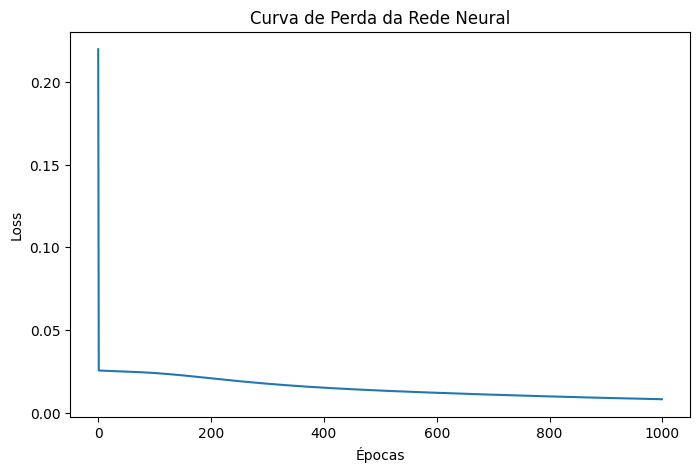

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(historico_loss)

plt.title("Curva de Perda da Rede Neural")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.show()

In [6]:
output_test = mlp.forward(X_test)

y_pred = (output_test > 0.5).astype(int)

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    "Acurácia:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precisão:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1-Score:",
    f1_score(y_test, y_pred)
)

Acurácia: 0.975
Precisão: 0.5
Recall: 0.3333333333333333
F1-Score: 0.4


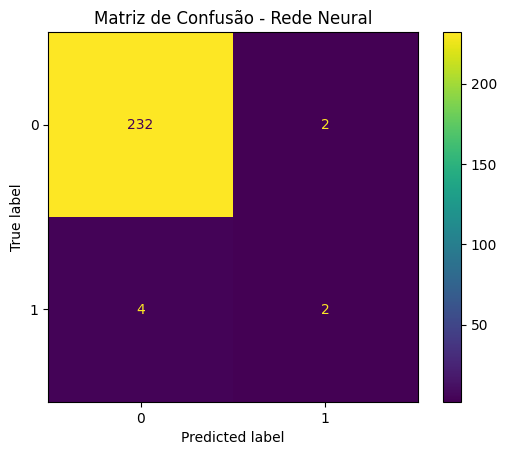

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title(
    "Matriz de Confusão - Rede Neural"
)

plt.show()

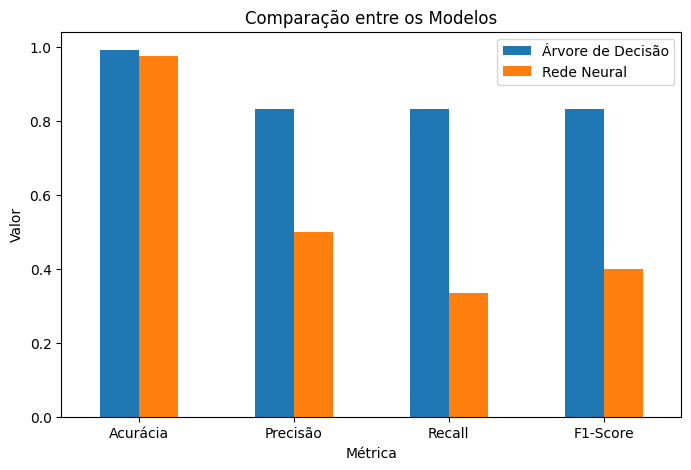

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão", "Recall", "F1-Score"],
    "Árvore de Decisão": [0.9917, 0.8333, 0.8333, 0.8333],
    "Rede Neural": [0.9750, 0.5000, 0.3333, 0.4000]
})

resultados.set_index("Métrica").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparação entre os Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=0)

plt.show()